# Part 1: Preprocessing the data

Dataset : https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv('Telco.csv')

In [4]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
dataset.shape

(7043, 21)

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
dataset.select_dtypes(include = 'str').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [9]:
len(dataset.select_dtypes(include = 'str').columns)

18

In [10]:
len(dataset.select_dtypes(include = ['float64', 'int64']).columns)

3

In [11]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
dataset.isnull().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [13]:
dataset.isnull().values.sum()

np.int64(0)

In [14]:
dataset.select_dtypes(include='str').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [18]:
dataset = dataset.drop(columns = ['customerID'])

In [19]:
dataset.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')

In [21]:
dataset.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
dataset.isnull().any()

gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges         True
Churn               False
dtype: bool

In [23]:
dataset.isnull().sum()


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [25]:
# This tells Pandas: "Show me ONLY the rows where TotalCharges is missing (NaN)"
dataset[dataset['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


/tmp/ipykernel_42754/3898914395.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=dataset, x='Churn', palette='Set2')


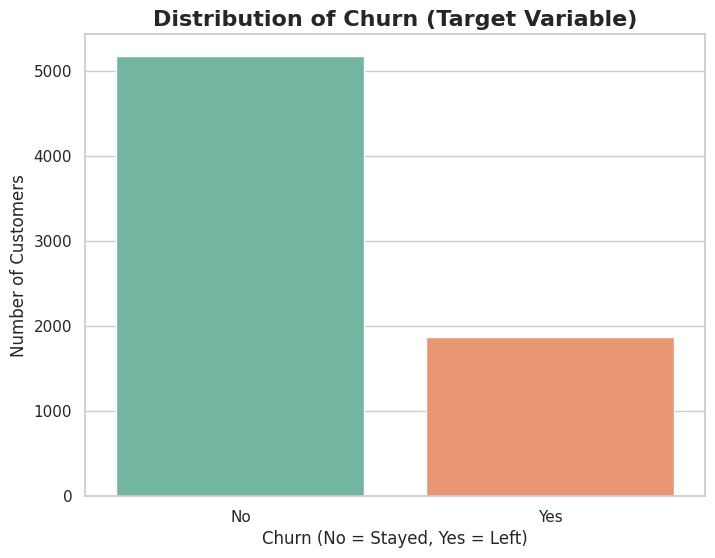

In [28]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

ax = sns.countplot(data=dataset, x='Churn', palette='Set2')

plt.title('Distribution of Churn (Target Variable)', fontsize=16, fontweight='bold')
plt.xlabel('Churn (No = Stayed, Yes = Left)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()

In [29]:
# The 'normalize=True' parameter calculates the percentage instead of the raw count
print(dataset['Churn'].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [30]:
# Map the Target Variable to binary integers
dataset['Churn'] = dataset['Churn'].map({'Yes': 1, 'No': 0})

# Check our work to make sure it converted properly
print(dataset['Churn'].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [31]:
# Automatically one-hot encode all remaining text columns
dataset = pd.get_dummies(dataset, drop_first=True, dtype=int)

# Check the new size of our dataset
print(dataset.shape)

(7043, 31)


In [32]:
dataset.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [33]:
from sklearn.model_selection import train_test_split

# 1. Separate the Target (y) from the Features (X)
X = dataset.drop('Churn', axis=1)
y = dataset['Churn']

# 2. Split into Training (80%) and Testing (20%) sets
# stratify=y is the secret weapon for imbalanced datasets!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Verify the split
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (5634, 30)
Testing data shape: (1409, 30)


In [34]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Identify the specific numerical columns we need to scale
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 3. FIT and TRANSFORM the training data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# 4. ONLY TRANSFORM the testing data (This is how you prevent Data Leakage!)
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 5. Verify the scaling worked
print("Scaling complete! Here is a peek at the scaled training features:")
print(X_train[num_cols].head())

Scaling complete! Here is a peek at the scaled training features:
        tenure  MonthlyCharges  TotalCharges
3738  0.102371       -0.521976     -0.263695
3151 -0.711743        0.337478     -0.505076
4860 -0.793155       -0.809013     -0.751328
3867 -0.263980        0.284384     -0.174159
3810 -1.281624       -0.676279     -0.990822


In [36]:
# Play detective: Find and print ONLY the columns in the training data that contain missing values
missing_data = X_train.isnull().sum()
print(missing_data[missing_data > 0])

TotalCharges    8
dtype: int64


In [37]:
# Patch the missing values in both the training and testing sets
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(0)
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(0)

# Double-check that the surgery was successful
print("Missing in Training:", X_train['TotalCharges'].isnull().sum())
print("Missing in Testing:", X_test['TotalCharges'].isnull().sum())

Missing in Training: 0
Missing in Testing: 0


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the Baseline Model
# Setting random_state is critical to secure the "Reproducibility" marks!
baseline_model = LogisticRegression(random_state=42)

# 2. Train (Fit) the model using your clean training data
print("Training Baseline Model...")
baseline_model.fit(X_train, y_train)

# 3. Make predictions on the unseen testing data
y_pred_baseline = baseline_model.predict(X_test)

# 4. Evaluate the results
print("\n--- Baseline Model Results ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Training Baseline Model...

--- Baseline Model Results ---
Overall Accuracy: 0.8055

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [39]:
from xgboost import XGBClassifier

# 1. Initialize the XGBoost Classifier
xgb_model = XGBClassifier(random_state=42)

# 2. Train the model
print("Training XGBoost Model...")
xgb_model.fit(X_train, y_train)

# 3. Predict and Evaluate on the test data
y_pred_xgb = xgb_model.predict(X_test)

# 4. Print the results
print("\n--- XGBoost Model Results ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Training XGBoost Model...

--- XGBoost Model Results ---
Overall Accuracy: 0.7850

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [40]:
# 1. Calculate the exact imbalance ratio (Number of 0s divided by Number of 1s)
stayed_count = (y_train == 0).sum()
churned_count = (y_train == 1).sum()
imbalance_ratio = stayed_count / churned_count

print(f"Calculated Imbalance Ratio: {imbalance_ratio:.2f}")

# 2. Re-initialize XGBoost with the built-in imbalance fix
xgb_balanced = XGBClassifier(random_state=42, scale_pos_weight=imbalance_ratio)

# 3. Train the balanced model
print("Training Balanced XGBoost Model...")
xgb_balanced.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred_balanced = xgb_balanced.predict(X_test)

print("\n--- Balanced XGBoost Results ---")
print(classification_report(y_test, y_pred_balanced))

Calculated Imbalance Ratio: 2.77
Training Balanced XGBoost Model...

--- Balanced XGBoost Results ---
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.54      0.68      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



/tmp/ipykernel_42754/438051817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='magma')


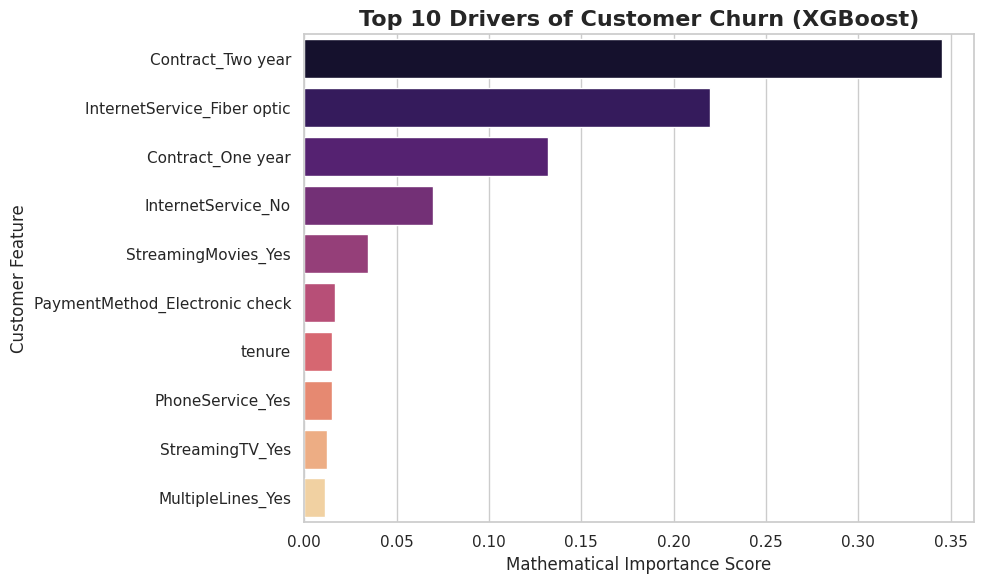

In [41]:
# 1. Extract the importance scores from your balanced model
importances = xgb_balanced.feature_importances_

# 2. Match the scores to your column names and sort them
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top 10 most critical drivers of churn
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='magma')

plt.title('Top 10 Drivers of Customer Churn (XGBoost)', fontsize=16, fontweight='bold')
plt.xlabel('Mathematical Importance Score', fontsize=12)
plt.ylabel('Customer Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [42]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the arena: The hyperparameter combinations to test
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# 2. Re-initialize the base model (We MUST keep our imbalance fix!)
xgb_base = XGBClassifier(random_state=42, scale_pos_weight=imbalance_ratio)

# 3. Set up the Randomized Search Tournament
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,          # Try 20 different random combinations
    scoring='f1',       # Grade them strictly on F1-Score, not accuracy!
    cv=3,               # 3-Fold Cross Validation
    verbose=2,          # Print the progress so we can watch it work
    random_state=42,
    n_jobs=-1           # Use all available CPU cores to speed it up
)

# 4. Start the training!
print("Commencing Advanced Hyperparameter Tuning... (This may take a minute)")
random_search.fit(X_train, y_train)

# 5. Reveal the ultimate winner
print("\n🏆 Best Parameters Found:")
print(random_search.best_params_)

Commencing Advanced Hyperparameter Tuning... (This may take a minute)
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.6, learning_rate=0.2, max_depth=4, n_estimators=300, subsample=0.6; total time=   6.0s[CV] END colsample_bytree=0.6, learning_rate=0.2, max_depth=4, n_estimators=300, subsample=0.6; total time=   6.0s

[CV] END colsample_bytree=0.6, learning_rate=0.2, max_depth=4, n_estimators=300, subsample=0.6; total time=   6.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time=   6.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time=   6.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time=   6.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=8, n_estimators=100, subsample=1.0; total time=   6.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth

In [43]:
# 1. Initialize the ultimate model with the winning parameters
# (We MUST keep the imbalance fix to prevent it from ignoring the minority class!)
xgb_final = XGBClassifier(
    random_state=42,
    scale_pos_weight=imbalance_ratio,
    learning_rate=0.01,
    max_depth=6,
    n_estimators=200,
    subsample=0.6,
    colsample_bytree=0.6
)

# 2. Train the final model
print("Training Final Optimized XGBoost Model...")
xgb_final.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_final = xgb_final.predict(X_test)

print("\n--- Final Tuned XGBoost Results ---")
print(classification_report(y_test, y_pred_final))

Training Final Optimized XGBoost Model...

--- Final Tuned XGBoost Results ---
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.80      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [44]:
import joblib

# 1. Export the highly-tuned XGBoost model
joblib.dump(xgb_final, 'churn_xgboost_model.joblib')

# 2. Export the exact scaler used on the training data
joblib.dump(scaler, 'churn_scaler.joblib')

print("Success! Model and Scaler are permanently saved to your hard drive.")

Success! Model and Scaler are permanently saved to your hard drive.


In [45]:
import requests

# 1. Grab the very first customer from your testing data
# We convert it to a dictionary so we can send it over the internet as JSON
test_customer = X_test.iloc[0].to_dict()

# 2. Define the URL of your local FastAPI server
url = "http://127.0.0.1:8000/predict"

# 3. Package the data exactly how our API expects it (inside a 'features' key)
payload = {"features": test_customer}

# 4. 'POST' the data to the server and wait for the AI's prediction
print("Sending customer data to the live API...")
response = requests.post(url, json=payload)

# 5. Print the server's official response!
print("\n--- API Response ---")
print(response.json())

Sending customer data to the live API...

--- API Response ---
{'status': 'success', 'prediction': 'Stay (Low Risk)'}
